# Deep Learning 0 — Introdução ao PyTorch

Link Colab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ftl-brazil-2026/ebook/blob/main/ml-dl/dl0_introducao_pytorch.ipynb)

Antes de construir redes neurais, precisamos conhecer a ferramenta e o "material" com que elas trabalham.

O **PyTorch** é a biblioteca de Deep Learning mais usada na pesquisa e cada vez mais na indústria. Ela oferece
três coisas:

1. **Tensors**: arrays multidimensionais, parecidos com os do NumPy, que também rodam em **GPU**;
2. ***Autograd***: cálculo automático de derivadas (veremos na aula 2);
3. **Blocos de redes neurais** prontos (`torch.nn`): camadas, funções de ativação, perdas, otimizadores.

**Roteiro desta aula**

1. O que é um tensor
2. Dimensões: escalar, vetor, matriz e além
3. Um tensor 2D e um tensor 3D na prática
4. Imagens como tensores: binária (1 canal) e colorida (3 canais)
5. O perceptron: o neurônio mais simples
6. Um MLP aprendendo um polinômio de grau 5

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch
import torch
import torch.nn as nn


AZUL, LARANJA, VERDE, CINZA, TINTA = "#2a78d6", "#eb6834", "#1baf7a", "#898781", "#52514e"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": CINZA, "axes.labelcolor": TINTA,
    "xtick.color": TINTA, "ytick.color": TINTA,
    "axes.grid": True, "grid.color": "#e6e5e1", "figure.dpi": 110,
})

torch.manual_seed(42)
print(f"PyTorch {torch.__version__}")
print(f"GPU (CUDA) disponível? {torch.cuda.is_available()}")

PyTorch 2.14.1
GPU (CUDA) disponível? False


## 1. O que é um tensor?

Um **tensor** é uma coleção de números organizada em uma grade com qualquer número de **dimensões** (também
chamadas de **eixos**). Todo dado que entra em uma rede neural (uma tabela, uma imagem, um vídeo, uma série
temporal) vira um tensor, e todos os pesos da rede também são tensores.

Criar um tensor é parecido com criar um array do NumPy:

In [2]:
t = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])
print(t)
print()
print(f"shape  (formato):            {t.shape}")
print(f"ndim   (nº de dimensões):    {t.ndim}")
print(f"numel  (nº de elementos):    {t.numel()}")
print(f"dtype  (tipo dos números):   {t.dtype}")
print(f"device (onde está guardado): {t.device}")

tensor([[1., 2., 3.],
        [4., 5., 6.]])

shape  (formato):            torch.Size([2, 3])
ndim   (nº de dimensões):    2
numel  (nº de elementos):    6
dtype  (tipo dos números):   torch.float32
device (onde está guardado): cpu


Os quatro atributos que você vai consultar o tempo todo:

| Atributo | O que diz | Por que importa |
|---|---|---|
| `shape` | o tamanho de cada dimensão | a maioria dos erros em Deep Learning é de formato incompatível |
| `ndim` | quantas dimensões | escalar = 0, vetor = 1, matriz = 2, ... |
| `dtype` | tipo dos números (`float32`, `int64`, `uint8`, ...) | redes trabalham com `float32`; rótulos de classe com `int64` |
| `device` | `cpu` ou `cuda` (GPU) | dois tensores só operam juntos se estiverem no mesmo lugar |

Tensores e arrays do NumPy se convertem facilmente:

In [3]:
a = np.array([1, 2, 3])
t_de_numpy = torch.from_numpy(a)           # NumPy -> PyTorch
volta_para_numpy = t_de_numpy.numpy()      # PyTorch -> NumPy
print(t_de_numpy, type(t_de_numpy))
print(volta_para_numpy, type(volta_para_numpy))

# mover para a GPU, se houver uma (no Colab: Ambiente de execução → Alterar o tipo → GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\ntensor no dispositivo: {t.to(device).device}")

tensor([1, 2, 3]) <class 'torch.Tensor'>
[1 2 3] <class 'numpy.ndarray'>

tensor no dispositivo: cpu


## 2. Dimensões: escalar, vetor, matriz e além

O número de dimensões é o número de **índices** necessários para chegar a um único número:

| ndim | Nome | Exemplo de `shape` | Exemplo de dado |
|---|---|---|---|
| 0 | escalar | `()` | a temperatura de hoje |
| 1 | vetor | `(4,)` | as 4 variáveis de uma amostra |
| 2 | matriz | `(3, 4)` | uma tabela: 3 linhas × 4 colunas; uma imagem em tons de cinza |
| 3 | tensor 3D | `(3, 3, 4)` | uma imagem colorida (canais × altura × largura) |
| 4 | tensor 4D | `(64, 3, 28, 28)` | um **lote** de 64 imagens coloridas |

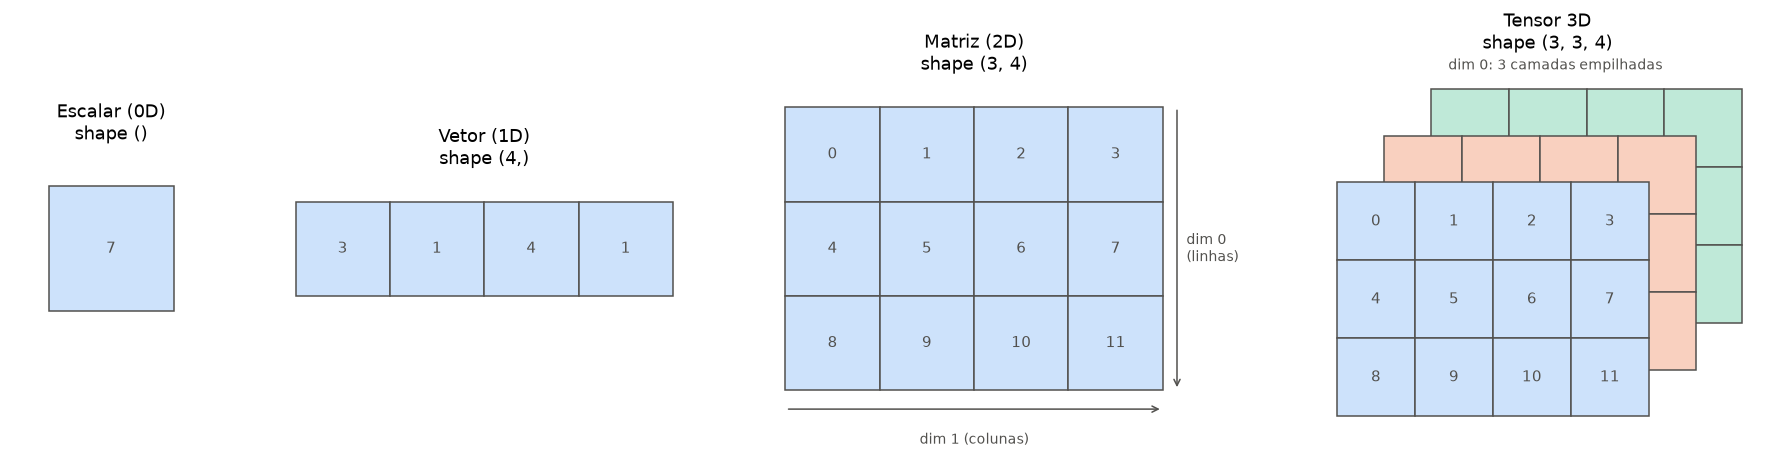

In [4]:
def desenha_grade(ax, valores, x0=0.0, y0=0.0, cor=AZUL, alpha=0.25, tamanho=1.0, texto=True):
    """Desenha uma matriz como uma grade de células, com o canto superior esquerdo em (x0, y0)."""
    valores = np.atleast_2d(valores)
    linhas, colunas = valores.shape
    for i in range(linhas):
        for j in range(colunas):
            x, y = x0 + j * tamanho, y0 - (i + 1) * tamanho
            ax.add_patch(Rectangle((x, y), tamanho, tamanho, facecolor=cor, alpha=alpha, edgecolor=TINTA, lw=1))
            if texto:
                ax.text(x + tamanho / 2, y + tamanho / 2, f"{valores[i, j]:g}", ha="center", va="center",
                        color=TINTA, fontsize=10)

escalar = torch.tensor(7)
vetor = torch.tensor([3, 1, 4, 1])
matriz = torch.arange(12).reshape(3, 4)
tensor3d = torch.arange(36).reshape(3, 3, 4)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2), width_ratios=[0.6, 1.3, 1.3, 1.8])
desenha_grade(axes[0], escalar.numpy(), 0, 1, cor="#cde2fb", alpha=1)
desenha_grade(axes[1], vetor.numpy(), 0, 1, cor="#cde2fb", alpha=1)
desenha_grade(axes[2], matriz.numpy(), 0, 3, cor="#cde2fb", alpha=1)
for k, cor in zip(range(2, -1, -1), ["#bfe9d8", "#f9d0bf", "#cde2fb"]):   # desenha do fundo para a frente
    desenha_grade(axes[3], tensor3d[k].numpy(), 0.6 * k, 3 + 0.6 * k, cor=cor, alpha=1, texto=(k == 0))

titulos = [f"Escalar (0D)\nshape {tuple(escalar.shape)}", f"Vetor (1D)\nshape {tuple(vetor.shape)}",
           f"Matriz (2D)\nshape {tuple(matriz.shape)}", f"Tensor 3D\nshape {tuple(tensor3d.shape)}"]
limites = [(-0.3, 1.3, -0.3, 1.3), (-0.3, 4.3, -0.3, 1.3), (-0.3, 4.3, -0.3, 3.3), (-0.3, 5.7, -0.3, 4.6)]
for ax, titulo, (x0, x1, y0, y1) in zip(axes, titulos, limites):
    ax.set(xlim=(x0, x1), ylim=(y0, y1), title=titulo)
    ax.set_aspect("equal")
    ax.axis("off")
axes[2].annotate("", xy=(4.15, 0), xytext=(4.15, 3), arrowprops={"arrowstyle": "->", "color": TINTA})
axes[2].text(4.25, 1.5, "dim 0\n(linhas)", va="center", fontsize=9, color=TINTA)
axes[2].annotate("", xy=(4, -0.2), xytext=(0, -0.2), arrowprops={"arrowstyle": "->", "color": TINTA})
axes[2].text(2, -0.45, "dim 1 (colunas)", ha="center", va="top", fontsize=9, color=TINTA)
axes[3].text(2.8, 4.45, "dim 0: 3 camadas empilhadas", ha="center", fontsize=9, color=TINTA)
plt.tight_layout()
plt.show()

## 3. Tensores 2D e 3D na prática

### Um tensor 2D: uma tabela

Imagine a temperatura máxima (°C) de 3 cidades em 4 dias. A **dimensão 0** são as cidades (linhas) e a
**dimensão 1** são os dias (colunas).

In [4]:
temperaturas = torch.tensor([[31.0, 29.5, 33.2, 30.1],    # Santos
                             [27.4, 26.8, 28.0, 25.9],    # São Paulo
                             [35.1, 34.7, 36.3, 35.8]])   # Cuiabá
print(f"shape: {tuple(temperaturas.shape)}  → 3 cidades × 4 dias\n")

print(f"temperaturas[0]       = {temperaturas[0]}   ← linha 0: Santos, os 4 dias")
print(f"temperaturas[:, 2]    = {temperaturas[:, 2]}   ← coluna 2: as 3 cidades no 3º dia")
print(f"temperaturas[2, 3]    = {temperaturas[2, 3].item():.1f}                                 ← um único número: Cuiabá, 4º dia")

shape: (3, 4)  → 3 cidades × 4 dias

temperaturas[0]       = tensor([31.0000, 29.5000, 33.2000, 30.1000])   ← linha 0: Santos, os 4 dias
temperaturas[:, 2]    = tensor([33.2000, 28.0000, 36.3000])   ← coluna 2: as 3 cidades no 3º dia
temperaturas[2, 3]    = 35.8                                 ← um único número: Cuiabá, 4º dia


Muitas operações recebem um argumento `dim`: ele diz **qual dimensão desaparece** no resultado.

- `dim=0` percorre as linhas → resultado por **coluna** (média de cada dia, entre as cidades)
- `dim=1` percorre as colunas → resultado por **linha** (média de cada cidade, entre os dias)

In [5]:
temperaturas

tensor([[31.0000, 29.5000, 33.2000, 30.1000],
        [27.4000, 26.8000, 28.0000, 25.9000],
        [35.1000, 34.7000, 36.3000, 35.8000]])

In [6]:
print(f"média por dia    (dim=0): {temperaturas.mean(dim=0)}   shape {tuple(temperaturas.mean(dim=0).shape)}")
print(f"média por cidade (dim=1): {temperaturas.mean(dim=1)}          shape {tuple(temperaturas.mean(dim=1).shape)}")
print(f"média geral:              {temperaturas.mean():.2f}                          shape {tuple(temperaturas.mean().shape)}")

média por dia    (dim=0): tensor([31.1667, 30.3333, 32.5000, 30.6000])   shape (4,)
média por cidade (dim=1): tensor([30.9500, 27.0250, 35.4750])          shape (3,)
média geral:              31.15                          shape ()


### Um tensor 3D: várias tabelas empilhadas

Agora a temperatura das 3 cidades em 4 dias, para **2 semanas**. Basta empilhar duas tabelas: a nova
dimensão 0 são as semanas.

In [7]:
semana2 = temperaturas + torch.randn(3, 4)          # a 2ª semana: valores parecidos com ruído
duas_semanas = torch.stack([temperaturas, semana2])  # empilha ao longo de uma nova dimensão 0
print(f"shape: {tuple(duas_semanas.shape)}  → 2 semanas × 3 cidades × 4 dias\n")

print(f"duas_semanas[1].shape        = {tuple(duas_semanas[1].shape)}    a 2ª semana inteira (uma tabela)")
print(f"duas_semanas[:, 0].shape     = {tuple(duas_semanas[:, 0].shape)}    Santos nas 2 semanas")
print(f"duas_semanas[1, 2, 0]        = {duas_semanas[1, 2, 0]:.1f}      Cuiabá, 2ª semana, 1º dia")
print(f"média por semana (dim=(1,2)) = {duas_semanas.mean(dim=(1, 2))}")

shape: (2, 3, 4)  → 2 semanas × 3 cidades × 4 dias

duas_semanas[1].shape        = (3, 4)    a 2ª semana inteira (uma tabela)
duas_semanas[:, 0].shape     = (2, 4)    Santos nas 2 semanas
duas_semanas[1, 2, 0]        = 36.5      Cuiabá, 2ª semana, 1º dia
média por semana (dim=(1,2)) = tensor([31.1500, 31.3599])


**Mudar o formato** sem mudar os dados é muito comum. `reshape` reorganiza os mesmos números em outra
grade; `flatten` achata tudo em um vetor. A única regra: o número total de elementos não muda.

In [9]:
x = torch.arange(24)
print(f"original:          {tuple(x.shape)}")
print(f"reshape(2, 3, 4):  {tuple(x.reshape(2, 3, 4).shape)}")
print(f"reshape(6, -1):    {tuple(x.reshape(6, -1).shape)}")
print(f"flatten de (2,3,4): {tuple(x.reshape(2, 3, 4).flatten().shape)}")

original:          (24,)
reshape(2, 3, 4):  (2, 3, 4)
reshape(6, -1):    (6, 4)
flatten de (2,3,4): (24,)


## 4. Imagens como tensores

### Imagem binária, 1 canal

Uma imagem em preto e branco é uma **matriz** de pixels: 1 = pixel aceso, 0 = apagado. No PyTorch, imagens
seguem a convenção **`(C, H, W)`**: canais, altura, largura. Uma imagem binária tem **1 canal**, então o
formato é `(1, H, W)`.

Vamos desenhar à mão um dígito "7" em uma grade de 8 × 8:

shape: (1, 8, 8)  (canais, altura, largura)
valores únicos: [0.0, 1.0]


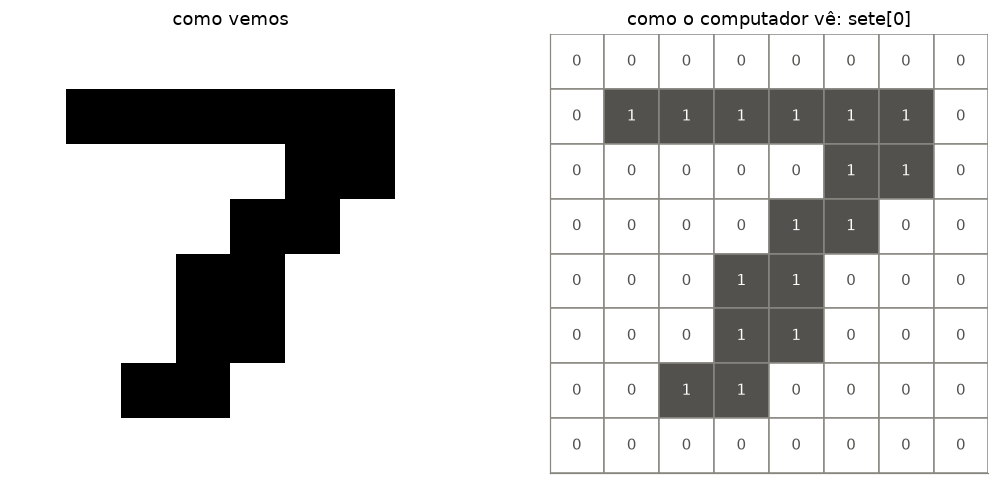

In [12]:
sete = torch.tensor([[0, 0, 0, 0, 0, 0, 0, 0],
                     [0, 1, 1, 1, 1, 1, 1, 0],
                     [0, 0, 0, 0, 0, 1, 1, 0],
                     [0, 0, 0, 0, 1, 1, 0, 0],
                     [0, 0, 0, 1, 1, 0, 0, 0],
                     [0, 0, 0, 1, 1, 0, 0, 0],
                     [0, 0, 1, 1, 0, 0, 0, 0],
                     [0, 0, 0, 0, 0, 0, 0, 0]], dtype=torch.float32).unsqueeze(0)   # (8, 8) → (1, 8, 8)

print(f"shape: {tuple(sete.shape)}  (canais, altura, largura)")
print(f"valores únicos: {sete.unique().tolist()}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].imshow(sete[0], cmap="gray_r", vmin=0, vmax=1)
axes[0].set_title("como vemos")
for i in range(8):
    for j in range(8):
        v = int(sete[0, i, j])
        axes[1].add_patch(Rectangle((j, 7 - i), 1, 1, facecolor=TINTA if v else "white", edgecolor=CINZA))
        axes[1].text(j + 0.5, 7.5 - i, v, ha="center", va="center", color="white" if v else TINTA)
axes[1].set(xlim=(0, 8), ylim=(0, 8), title="como o computador vê: sete[0]")
axes[1].set_aspect("equal")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
axes[0].axis("off")
plt.tight_layout()
plt.show()

### Imagem colorida, 3 canais (RGB)

Uma imagem colorida tem **3 canais**: vermelho (R), verde (G) e azul (B). Cada canal é uma matriz com a
intensidade daquela cor, de 0 a 1. O formato fica `(3, H, W)`: um **tensor 3D**. A cor de cada pixel é a
mistura dos três canais: vermelho + verde = amarelo, os três no máximo = branco.

Vamos montar uma imagem de 8 × 8 com quatro quadrados coloridos:

shape: (3, 8, 8)   (canais, altura, largura)


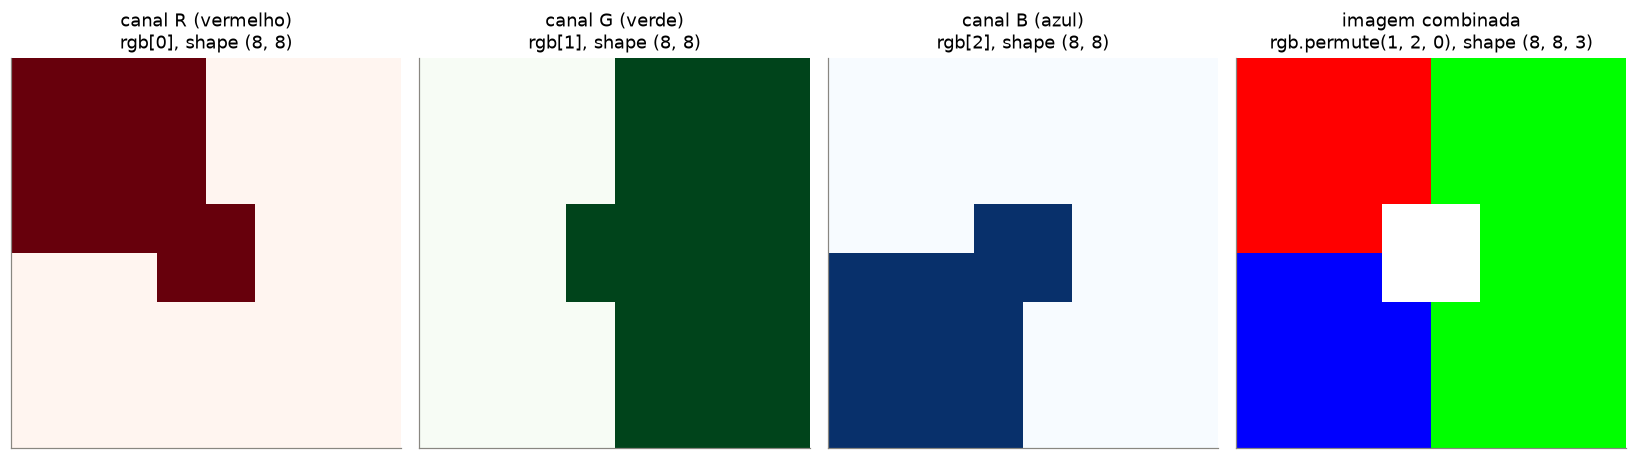

In [14]:
rgb = torch.zeros(3, 8, 8)            # (canais, altura, largura), tudo preto
rgb[0, :4, :4] = 1.0                  # canto superior esquerdo: só vermelho         vermelho
rgb[1, :4, 4:] = 1.0                  # canto superior direito: só verde             verde
rgb[2, 4:, :4] = 1.0                  # canto inferior esquerdo: só azul             amarelo
rgb[1, 4:, 4:] = 1.0
rgb[:, 3:5, 3:5] = 1.0                # centro: os três canais no máximo            branco

print(f"shape: {tuple(rgb.shape)}   (canais, altura, largura)")

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, c, nome, cmap in zip(axes, range(3), ["canal R (vermelho)", "canal G (verde)", "canal B (azul)"],
                             ["Reds", "Greens", "Blues"]):
    ax.imshow(rgb[c], cmap=cmap, vmin=0, vmax=1)
    ax.set_title(f"{nome}\nrgb[{c}], shape {tuple(rgb[c].shape)}")
# o matplotlib espera (H, W, C): permute reordena as dimensões
axes[3].imshow(rgb.permute(1, 2, 0))
axes[3].set_title(f"imagem combinada\nrgb.permute(1, 2, 0), shape {tuple(rgb.permute(1, 2, 0).shape)}")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout()
plt.show()

Repare no `permute(1, 2, 0)`: o PyTorch guarda imagens como `(C, H, W)`, mas o matplotlib (e o NumPy, o
OpenCV, o PIL...) espera `(H, W, C)`. Reordenar as dimensões é uma das operações mais comuns do dia a dia.

### Lotes de imagens: 4 dimensões

Redes neurais processam várias imagens de uma vez, em um **lote** (*batch*). Empilhando imagens ganhamos mais
uma dimensão na frente: **`(N, C, H, W)`**. Uma imagem de satélite com 13 bandas (Sentinel-2) seria
`(13, H, W)`, e um lote de 16 delas `(16, 13, H, W)`: a mesma ideia, só com mais canais.

shape do lote: (4, 3, 8, 8)  → (imagens, canais, altura, largura)


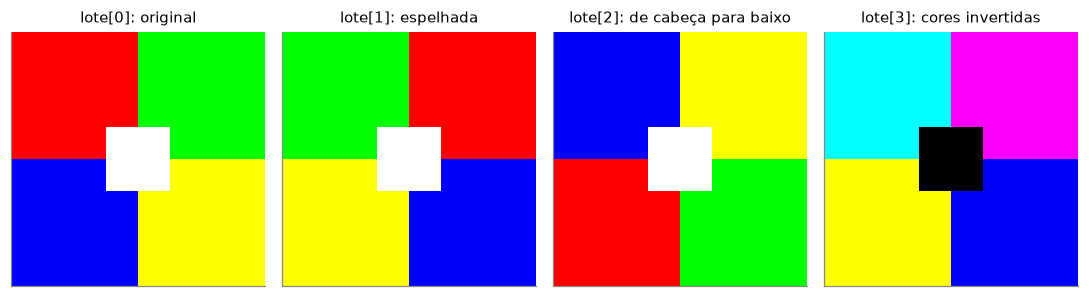

In [11]:
lote = torch.stack([rgb, rgb.flip(dims=[2]), rgb.flip(dims=[1]), 1 - rgb])   # 4 variações da imagem
print(f"shape do lote: {tuple(lote.shape)}  → (imagens, canais, altura, largura)")

fig, axes = plt.subplots(1, 4, figsize=(10, 2.8))
for i, (ax, titulo) in enumerate(zip(axes, ["original", "espelhada", "de cabeça para baixo", "cores invertidas"])):
    ax.imshow(lote[i].permute(1, 2, 0))
    ax.set_title(f"lote[{i}]: {titulo}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout()
plt.show()

## 5. O perceptron: o neurônio mais simples

O **perceptron** (Rosenblatt, 1958) é o ancestral de todas as redes neurais. Ele:

1. recebe entradas $x_1, x_2, \dots$;
2. multiplica cada uma por um **peso** $w_i$ e soma, mais um **viés** $b$: $z = w_1x_1 + w_2x_2 + b$;
3. aplica uma **função de ativação**. No perceptron original, um **degrau**: a saída é 1 se $z > 0$, senão 0.

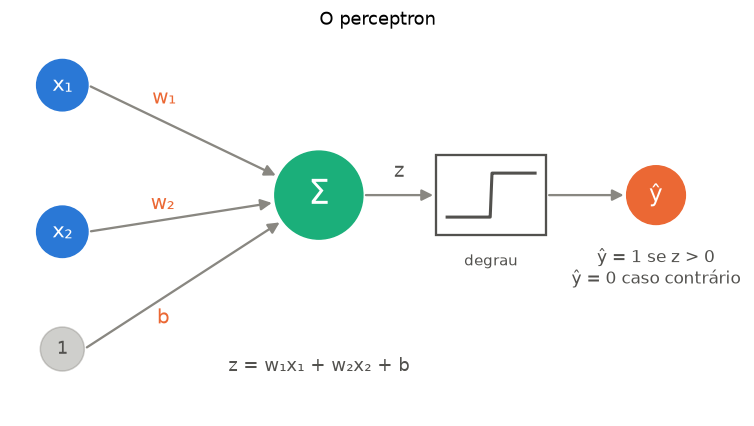

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4.5))

def seta(xy_de, xy_para, texto=None, pos=0.5, desloc=(0, 0.15)):
    ax.add_patch(FancyArrowPatch(xy_de, xy_para, arrowstyle="-|>", mutation_scale=15, color=CINZA, lw=1.5))
    if texto:
        xm = xy_de[0] + pos * (xy_para[0] - xy_de[0]) + desloc[0]
        ym = xy_de[1] + pos * (xy_para[1] - xy_de[1]) + desloc[1]
        ax.text(xm, ym, texto, ha="center", color=LARANJA, fontsize=13)

entradas = {"x₁": (0.5, 3.0), "x₂": (0.5, 1.0)}
for nome, (x, y) in entradas.items():
    ax.add_patch(Circle((x, y), 0.35, color=AZUL))
    ax.text(x, y, nome, ha="center", va="center", color="white", fontsize=14)
ax.add_patch(Circle((0.5, -0.6), 0.3, color=CINZA, alpha=0.4))
ax.text(0.5, -0.6, "1", ha="center", va="center", color=TINTA, fontsize=12)

soma = (4.0, 1.5)
ax.add_patch(Circle(soma, 0.6, color=VERDE))
ax.text(*soma, "Σ", ha="center", va="center", color="white", fontsize=22)
seta((0.85, 3.0), (3.45, 1.75), "w₁", pos=0.4, desloc=(0, 0.25))
seta((0.85, 1.0), (3.4, 1.4), "w₂", pos=0.4, desloc=(0, 0.15))
seta((0.8, -0.6), (3.5, 1.15), "b", pos=0.4, desloc=(0, -0.35))

ax.add_patch(Rectangle((5.6, 0.95), 1.5, 1.1, facecolor="white", edgecolor=TINTA, lw=1.5))
xs = np.linspace(5.75, 6.95, 50)
ax.plot(xs, np.where(xs > 6.35, 1.8, 1.2), color=TINTA, lw=2)
ax.text(6.35, 0.7, "degrau", ha="center", va="top", color=TINTA)
seta((4.6, 1.5), (5.6, 1.5))
ax.text(5.1, 1.75, "z", ha="center", color=TINTA, fontsize=13)

ax.add_patch(Circle((8.6, 1.5), 0.4, color=LARANJA))
ax.text(8.6, 1.5, "ŷ", ha="center", va="center", color="white", fontsize=15)
seta((7.1, 1.5), (8.2, 1.5))

ax.text(4.0, -0.9, "z = w₁x₁ + w₂x₂ + b", ha="center", color=TINTA, fontsize=12)
ax.text(8.6, 0.8, "ŷ = 1 se z > 0\nŷ = 0 caso contrário", ha="center", va="top", color=TINTA, fontsize=11)
ax.set(xlim=(-0.2, 9.8), ylim=(-1.5, 3.7))
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("O perceptron")
plt.show()

### Um perceptron que calcula o "E" lógico

Com os pesos certos, um perceptron implementa a porta lógica **E** (*AND*): a saída é 1 apenas quando as duas
entradas são 1. Com $w_1 = w_2 = 1$ e $b = -1{,}5$:

| $x_1$ | $x_2$ | $z = x_1 + x_2 - 1{,}5$ | $\hat{y}$ |
|---|---|---|---|
| 0 | 0 | −1,5 | 0 |
| 0 | 1 | −0,5 | 0 |
| 1 | 0 | −0,5 | 0 |
| 1 | 1 | +0,5 | 1 |

In [15]:
class Perceptron(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)                 # z = w·x + b

    def forward(self, x):
        z = self.linear(x)
        return (z > 0).float()                        # degrau

perceptron = Perceptron()
with torch.no_grad():                                  # definimos os pesos à mão (sem treino)
    perceptron.linear.weight.copy_(torch.tensor([[1.0, 1.0]]))
    perceptron.linear.bias.copy_(torch.tensor([-1.5]))

entradas_and = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
saidas = perceptron(entradas_and)
for x, y in zip(entradas_and, saidas):
    print(f"x = {x.tolist()}  →  ŷ = {int(y.item())}")

x = [0.0, 0.0]  →  ŷ = 0
x = [0.0, 1.0]  →  ŷ = 0
x = [1.0, 0.0]  →  ŷ = 0
x = [1.0, 1.0]  →  ŷ = 1


Geometricamente, o perceptron traça uma **reta** ($w_1x_1 + w_2x_2 + b = 0$) e classifica cada ponto pelo lado
em que ele cai:

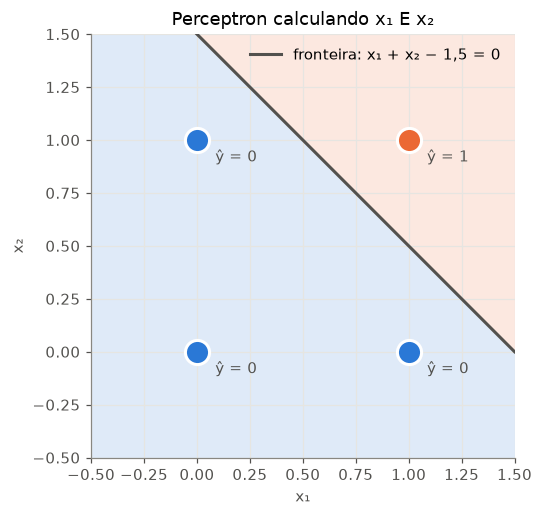

In [14]:
g1, g2 = torch.meshgrid(torch.linspace(-0.5, 1.5, 300), torch.linspace(-0.5, 1.5, 300), indexing="xy")
grade = torch.stack([g1.flatten(), g2.flatten()], dim=1)
with torch.no_grad():
    regioes = perceptron(grade).reshape(300, 300)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.contourf(g1, g2, regioes, levels=[-0.5, 0.5, 1.5], colors=[AZUL, LARANJA], alpha=0.15)
ax.plot([-0.5, 1.5], [2.0, 0.0], color=TINTA, lw=2, label="fronteira: x₁ + x₂ − 1,5 = 0")
for x, y in zip(entradas_and, saidas):
    ax.scatter(*x, s=250, color=LARANJA if y else AZUL, edgecolor="white", lw=2, zorder=3)
    ax.annotate(f"ŷ = {int(y)}", x, xytext=(12, -14), textcoords="offset points", color=TINTA)
ax.set(xlim=(-0.5, 1.5), ylim=(-0.5, 1.5), xlabel="x₁", ylabel="x₂", title="Perceptron calculando x₁ E x₂")
ax.set_aspect("equal")
ax.legend(frameon=False, loc="upper right")
plt.show()

Uma única reta é também o **limite** do perceptron: ele só separa classes que uma reta consegue separar.
Problemas mais complicados exigem **várias camadas** de neurônios, com ativações não lineares entre elas: um
**MLP** (*Multi-Layer Perceptron*).

## 6. Um MLP aprendendo um polinômio de grau 5

Vamos dar ao MLP uma tarefa que nenhuma reta resolve: aprender a curva de um **polinômio de grau 5**,

$$p(x) = x^5 - 5x^3 + 4x = x(x^2 - 1)(x^2 - 4)$$

que cruza o zero 5 vezes. Só que a rede **não conhece a fórmula**: ela só vê 200 pontos $(x, y)$ com ruído,
como se fossem medições. A rede tem 1 entrada ($x$), duas camadas escondidas de 32 neurônios e 1 saída ($\hat{y}$).

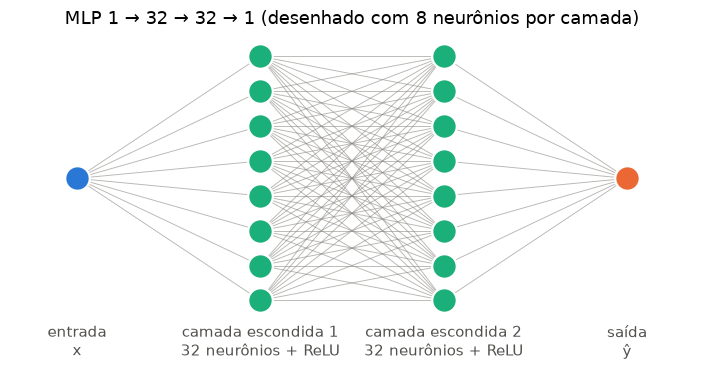

In [15]:
def desenha_mlp(ax, camadas, rotulos, titulo):
    xs = np.linspace(0, 1, len(camadas))
    pos = []
    for x, n_neur in zip(xs, camadas):
        ys = np.linspace(0.5 - 0.09 * (n_neur - 1), 0.5 + 0.09 * (n_neur - 1), n_neur)
        pos.append([(x, y) for y in ys])
    for a, b in zip(pos[:-1], pos[1:]):
        for (x0, y0) in a:
            for (x1, y1) in b:
                ax.plot([x0, x1], [y0, y1], color=CINZA, lw=0.6, alpha=0.6, zorder=1)
    cores = [AZUL] + [VERDE] * (len(camadas) - 2) + [LARANJA]
    for camada, cor in zip(pos, cores):
        for (x, y) in camada:
            ax.scatter(x, y, s=260, color=cor, zorder=2, edgecolor="white", lw=1.5)
    for x, r in zip(xs, rotulos):
        ax.text(x, -0.25, r, ha="center", va="top", color=TINTA, fontsize=10)
    ax.set(xlim=(-0.12, 1.12), ylim=(-0.5, 1.25), title=titulo)
    ax.axis("off")

fig, ax = plt.subplots(figsize=(8, 4))
desenha_mlp(ax, [1, 8, 8, 1], ["entrada\nx", "camada escondida 1\n32 neurônios + ReLU",
                               "camada escondida 2\n32 neurônios + ReLU", "saída\nŷ"],
            "MLP 1 → 32 → 32 → 1 (desenhado com 8 neurônios por camada)")
plt.show()

In [16]:
def polinomio(x):
    return x ** 5 - 5 * x ** 3 + 4 * x

torch.manual_seed(0)
x_dados = torch.rand(200, 1) * 4.4 - 2.2                     # 200 pontos sorteados em [-2,2; 2,2]
y_dados = polinomio(x_dados) + 0.5 * torch.randn(200, 1)     # medições com ruído
x_curva = torch.linspace(-2.2, 2.2, 400).unsqueeze(1)

mlp = nn.Sequential(
    nn.Linear(1, 32), nn.ReLU(),
    nn.Linear(32, 32), nn.ReLU(),
    nn.Linear(32, 1),
)
print(mlp)
print(f"parâmetros: {sum(p.numel() for p in mlp.parameters()):,}")

Sequential(
  (0): Linear(in_features=1, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)
parâmetros: 1,153


O treino abaixo usa peças que veremos em detalhe nas próximas aulas: uma **perda** que mede o erro (aula 2), o
`backward()` que calcula como ajustar cada peso (aula 2) e um **otimizador** que aplica o ajuste (aula 3). Por
enquanto, observe o resultado: guardamos a curva da rede em alguns momentos do treino.

In [17]:
otimizador = torch.optim.Adam(mlp.parameters(), lr=0.01)
momentos = [0, 50, 200, 2000]
curvas, perdas = {}, []

for passo in range(2001):
    if passo in momentos:
        with torch.no_grad():
            curvas[passo] = mlp(x_curva).clone()
    otimizador.zero_grad()
    perda = ((mlp(x_dados) - y_dados) ** 2).mean()   # erro quadrático médio
    perda.backward()
    otimizador.step()
    perdas.append(perda.item())

print(f"erro quadrático médio: início = {perdas[0]:.2f}   final = {perdas[-1]:.3f}  (o ruído sozinho dá ≈ 0,25)")

erro quadrático médio: início = 4.82   final = 0.233  (o ruído sozinho dá ≈ 0,25)


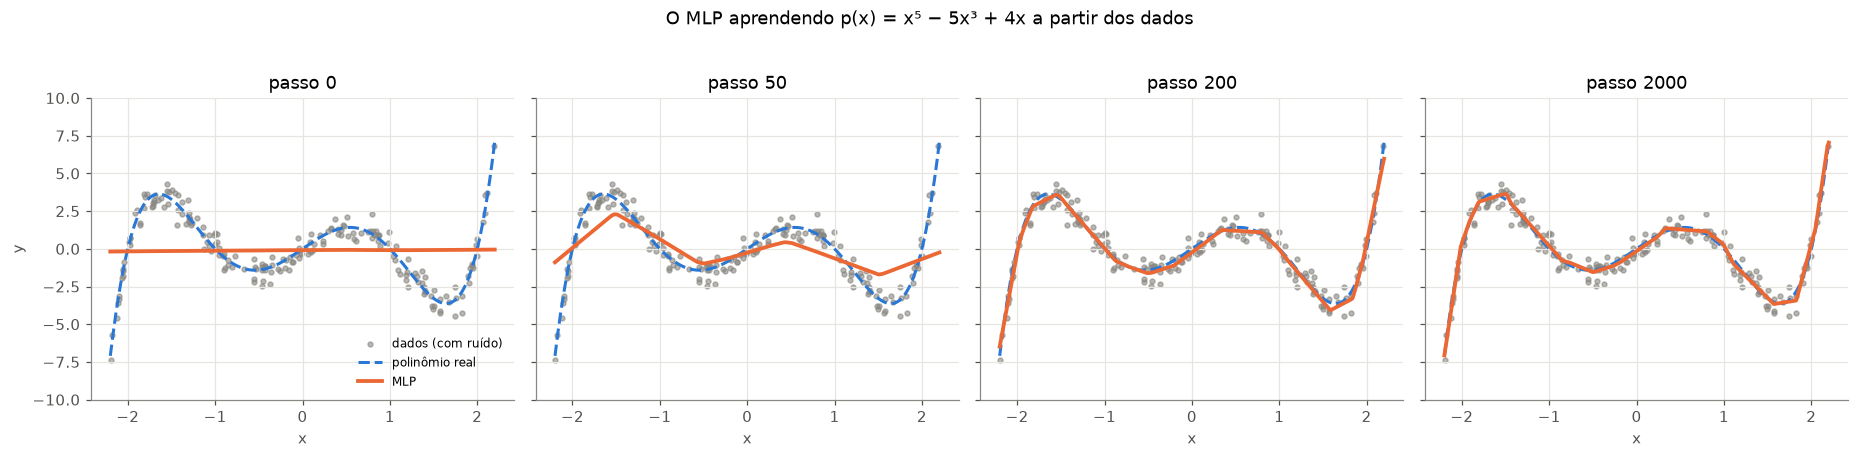

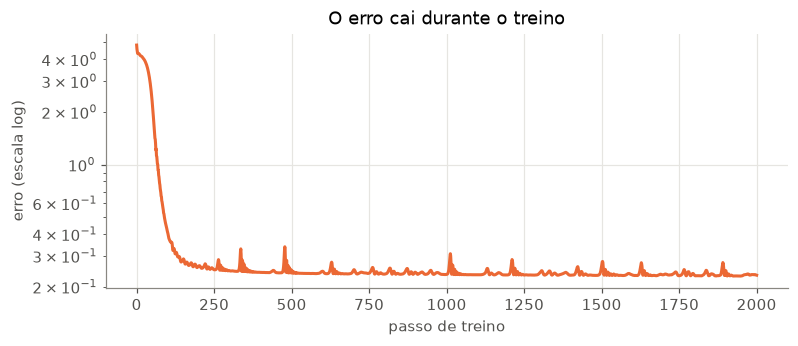

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4), sharey=True)
for ax, passo in zip(axes, momentos):
    ax.scatter(x_dados, y_dados, s=10, color=CINZA, alpha=0.6, label="dados (com ruído)")
    ax.plot(x_curva, polinomio(x_curva), color=AZUL, lw=2, ls="--", label="polinômio real")
    ax.plot(x_curva, curvas[passo], color=LARANJA, lw=2.5, label="MLP")
    ax.set(title=f"passo {passo}", xlabel="x", ylim=(-10, 10))
axes[0].set_ylabel("y")
axes[0].legend(frameon=False, loc="lower right", fontsize=8)
plt.suptitle("O MLP aprendendo p(x) = x⁵ − 5x³ + 4x a partir dos dados", y=1.03)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(perdas, color=LARANJA, lw=2)
ax.set(yscale="log", xlabel="passo de treino", ylabel="erro (escala log)", title="O erro cai durante o treino")
plt.show()

No passo 0 a rede, com pesos aleatórios, é praticamente uma reta. Ao longo do treino ela vai "dobrando" a
curva até seguir o polinômio, **sem nunca ter visto a fórmula**: só os pontos. É isso que uma rede neural faz:
aprende uma função a partir de exemplos.

Repare também que a curva final é feita de **pequenos trechos retos**: cada neurônio ReLU contribui com uma
"dobra". Na aula 1 veremos por que isso funciona.

## 7. Resumo

- **Tensor** = grade de números com qualquer número de dimensões. Atributos-chave: `shape`, `ndim`, `dtype`, `device`.
- Escalar (0D) → vetor (1D) → matriz (2D) → tensor 3D → 4D... Em operações como `mean(dim=...)`, `dim` diz qual
  dimensão desaparece.
- **Imagens** no PyTorch são `(C, H, W)`: 1 canal (cinza/binária) ou 3 canais (RGB). Lotes de imagens são
  `(N, C, H, W)`. Para o matplotlib, use `permute(1, 2, 0)`.
- O **perceptron** faz uma soma ponderada mais um viés e aplica um degrau: separa as classes com uma reta.
- Um **MLP** empilha camadas de neurônios com ativações não lineares e aprende curvas complexas a partir dos dados.

### Exercícios

1. Crie um tensor com `shape (2, 3, 4, 5)`. Quantos elementos ele tem? Qual o `shape` de `t.mean(dim=1)`?
2. Desenhe o seu próprio dígito (por exemplo, um "1" ou um "4") em uma grade 8 × 8 e mostre com `imshow`.
3. Na imagem RGB, pinte o centro de **magenta** (vermelho + azul). Quais canais você precisa ligar?
4. Mude o viés do perceptron para $b = -0{,}5$. Que porta lógica ele passa a calcular?
5. No MLP, troque o polinômio por $\sin(3x)$ e reduza a rede para 1 → 8 → 1. A rede ainda consegue aprender?